In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax

from data_config import get_config

In [2]:
config = get_config('cifar10_r56')
config.par_calib = 0.1
config.num_calib = int(config.num_samples * config.par_calib)


In [3]:
with open(config.file_name, 'rb') as file:
    data = pickle.load(file)

labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
    data["labels"], softmax(data["preds"], 1), test_size=config.par_calib, random_state=42
)

eval_data = {"labels": labels_eval, "scores": scores_eval}
calib_data = {"labels": labels_calib, "scores": scores_calib}


# Baselines APS

In [4]:
def calc_aps_scores(scores, labels, randomized=True):
    cal_pi = scores.argsort(1)[:, ::-1]
    cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
    cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
        range(len(labels)), labels
    ]
    if not randomized:
        cal_scores = cal_softmax_correct_class
    else:
        cumsum_index = np.where(cal_srt == cal_softmax_correct_class[:,None])[1]
        if cumsum_index.shape[0] != cal_srt.shape[0]:
            _, unique_indices = np.unique(np.where(
                cal_srt == cal_softmax_correct_class[:,None])[0], return_index=True)
            cumsum_index = cumsum_index[unique_indices]
        high = cal_softmax_correct_class
        low = np.zeros_like(high)
        low[cumsum_index != 0] = cal_srt[np.where(cumsum_index != 0)[0], cumsum_index[cumsum_index != 0]-1]
        cal_scores = np.random.uniform(low=low, high=high)
    return cal_scores


def get_aps_sets(scores, qhat, randomized=True, no_zero_size_sets=True):
    val_pi = scores.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(scores, val_pi, axis=1).cumsum(axis=1)
    if qhat.ndim:
        qhat = np.expand_dims(qhat, 1)
    if not randomized:
        prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)
    else:
        n_val = val_srt.shape[0]
        cumsum_index = np.sum(val_srt <= qhat, axis=1)
        high = val_srt[np.arange(n_val), cumsum_index]
        low = np.zeros_like(high)
        low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
        prob = (qhat - low)/(high - low)
        rv = np.random.binomial(1,prob,size=(n_val))
        randomized_threshold = low
        randomized_threshold[rv == 1] = high[rv == 1]
        if no_zero_size_sets:
            randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
        prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)
    return prediction_sets


In [5]:
randomized = False
no_zero_size_sets = True
alpha = 0.1

cal_smx = calib_data["scores"]
cal_labels = calib_data["labels"]
n = len(cal_labels)

val_smx = eval_data["scores"]
val_labels = eval_data["labels"]


cal_scores = calc_aps_scores(cal_smx, cal_labels, randomized)
qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
prediction_sets = get_aps_sets(val_smx, qhat, randomized, no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()

baseline_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Baseline mets:')
for key, value in baseline_mets.items():
    print(f"{key}: {value:.4f}")


Baseline mets:
size: 5.0391
coverage: 0.8721


# Ours method

In [6]:
cal_scores_est = calc_aps_scores(cal_smx, cal_smx.argmax(1), randomized)
residuales = calc_aps_scores(cal_smx, cal_labels, randomized) - cal_scores_est

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qhat = np.quantile(
    residuales, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

print('Qhat: {:.4f}'.format(qhat))
prediction_sets = get_aps_sets(val_smx, np.clip(val_smx.max(1) + qhat, a_min=val_smx.min(1), a_max=1.), randomized, no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()

ours_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours mets:')
for key, value in ours_mets.items():
    print(f"{key}: {value:.4f}")


Residuales: mean: 0.024 std: 0.086 min: 0.000 max: 0.716
Qhat: 0.0225
Ours mets:
size: 8.0392
coverage: 0.9136


Text(0.5, 1.0, 'Eval thresholds')

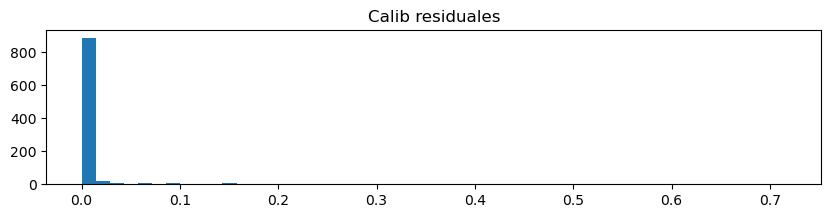

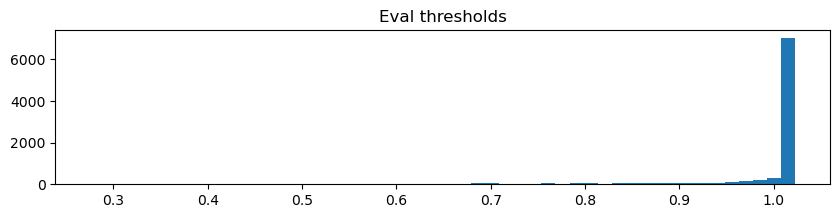

In [7]:
# debug #
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
_ = plt.hist(residuales, bins=50)
plt.title('Calib residuales')

plt.figure(figsize=(10, 2))
_ = plt.hist(val_smx.max(1) + qhat, bins=50)
plt.title('Eval thresholds')

# Ours 2 groups

In [8]:
above_calib_inds = np.where(cal_smx.max(1) > 1. - alpha)[0]
below_calib_inds = np.where(cal_smx.max(1) <= 1. - alpha)[0]
print(len(above_calib_inds), len(below_calib_inds))

cal_scores_above_est = calc_aps_scores(cal_smx[above_calib_inds, :], cal_smx.argmax(1)[above_calib_inds], randomized)
residuales_above = calc_aps_scores(cal_smx[above_calib_inds, :], cal_labels[above_calib_inds], randomized) - cal_scores_above_est
print('ABOVE')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_above.mean(), residuales_above.std(), residuales_above.min(), residuales_above.max()))

qhat_above = np.quantile(
    residuales_above, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_above))


cal_scores_below_est = calc_aps_scores(cal_smx[below_calib_inds, :], cal_smx.argmax(1)[below_calib_inds], randomized)
residuales_below = calc_aps_scores(cal_smx[below_calib_inds, :], cal_labels[below_calib_inds], randomized) - cal_scores_below_est
print('BELOW')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_below.mean(), residuales_below.std(), residuales_below.min(), residuales_below.max()))

qhat_below = np.quantile(
    residuales_below, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_below))


861 139
ABOVE
Residuales: mean: 0.002 std: 0.008 min: 0.000 max: 0.090
Qhat: 0.0000
BELOW
Residuales: mean: 0.160 std: 0.177 min: 0.000 max: 0.716
Qhat: 0.4281


In [9]:
above_val_inds = np.where(val_smx.argmax(1) > 1. - alpha)[0]
below_val_inds = np.where(val_smx.argmax(1) <= 1. - alpha)[0]

prediction_sets_above = get_aps_sets(
    val_smx[above_val_inds, :], 
    np.clip(val_smx[above_val_inds, :].max(1) + qhat_above,
            a_min=val_smx[above_val_inds, :].min(1),
            a_max=1.), randomized, no_zero_size_sets)

prediction_sets_below = get_aps_sets(
    val_smx[below_val_inds, :], 
    np.clip(val_smx[below_val_inds, :].max(1) + qhat_below,
            a_min=val_smx[below_val_inds, :].min(1),
            a_max=1.), randomized, no_zero_size_sets)

empirical_coverage = np.concatenate([
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), val_labels[above_val_inds]],
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), val_labels[below_val_inds]],
]).mean()

ours_two_groups_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours two groups mets:')
for key, value in ours_two_groups_mets.items():
    print(f"{key}: {value:.4f}")


Ours two groups mets:
size: 8.0392
coverage: 0.8740


In [13]:
import pandas as pd

metrics_list = [baseline_mets, ours_mets, ours_two_groups_mets]

df = pd.DataFrame(['Method', 'Size', 'Coverage'])
df.loc[0] = ['Baseline', baseline_mets['size'], baseline_mets['coverage']]
print(df)

ValueError: setting an array element with a sequence.